# Are Summers in Zurich Getting Warmer?
**Scientific Programming – Project Work FS2026**

Group: [enter group number]
Names: [enter names of all group members]

## Introduction
This project investigates whether summers in Zurich have become warmer over
the past decades. We analyse daily mean temperatures from 1950 to 2024.

**Research question:** Can a statistically significant warming trend be
identified for Zurich's summer months (June–August)?

## Setup: install required packages

In [7]:
%pip install requests pandas matplotlib seaborn scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Data Collection
We retrieve the daily mean temperatures for Zurich via the Open-Meteo
Web API (period 1950–2024).

In [8]:
import requests
import pandas as pd

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 47.37,
    "longitude": 8.54,
    "start_date": "1950-01-01",
    "end_date": "2024-12-31",
    "daily": "temperature_2m_mean",
    "timezone": "Europe/Berlin"
}

response = requests.get(url, params=params)
data = response.json()

df = pd.DataFrame({
    "datum": data["daily"]["time"],
    "temp_mittel": data["daily"]["temperature_2m_mean"]
})

df

,datum,temp_mittel
0,1950-01-01,-1.6
1,1950-01-02,0.7
2,1950-01-03,2.0
3,1950-01-04,1.5
4,1950-01-05,3.3
...,...,...
27389,2024-12-27,-1.5
27390,2024-12-28,-0.5
27391,2024-12-29,-0.1
27392,2024-12-30,-1.9


## 2. Data Preparation
We convert the date values into a proper date format and then filter
the data to the summer months June, July and August.

In [9]:

df["datum"] = pd.to_datetime(df["datum"])


df["jahr"] = df["datum"].dt.year
df["monat"] = df["datum"].dt.month

df

,datum,temp_mittel,jahr,monat
0,1950-01-01,-1.6,1950,1
1,1950-01-02,0.7,1950,1
2,1950-01-03,2.0,1950,1
3,1950-01-04,1.5,1950,1
4,1950-01-05,3.3,1950,1
...,...,...,...,...
27389,2024-12-27,-1.5,2024,12
27390,2024-12-28,-0.5,2024,12
27391,2024-12-29,-0.1,2024,12
27392,2024-12-30,-1.9,2024,12


In [10]:

sommer = df[df["monat"].isin([6, 7, 8])]


sommer_pro_jahr = sommer.groupby("jahr")["temp_mittel"].mean().reset_index()


sommer_pro_jahr = sommer_pro_jahr.rename(columns={"temp_mittel": "sommer_temp"})

sommer_pro_jahr

,jahr,sommer_temp
0,1950,19.178261
1,1951,17.344565
2,1952,19.378261
3,1953,16.882609
4,1954,15.759783
...,...,...
70,2020,18.765217
71,2021,18.139130
72,2022,20.392391
73,2023,20.025000


## 3. Visualisation
The chart shows the average summer temperature per year.
The red line is the trend line.

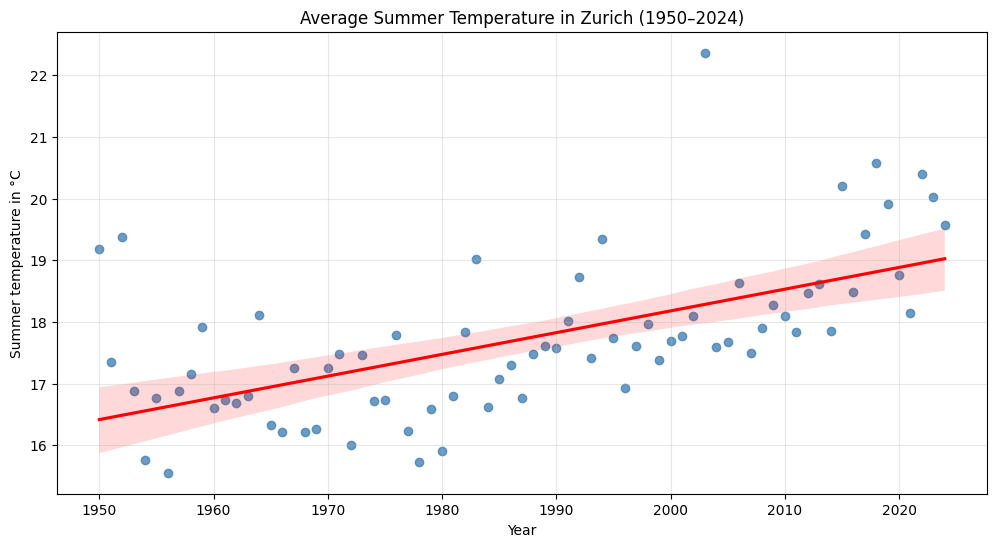

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.regplot(data=sommer_pro_jahr, x="jahr", y="sommer_temp",
            scatter_kws={"color": "steelblue"},
            line_kws={"color": "red"})
plt.title("Average Summer Temperature in Zurich (1950–2024)")
plt.xlabel("Year")
plt.ylabel("Summer temperature in °C")
plt.grid(True, alpha=0.3)
plt.show()

## 4. Statistical Analysis
We use a correlation test (Pearson) to check whether the trend is
statistically significant. The decisive measure is the p-value: if it
is below 0.05, the relationship is considered significant.

In [12]:
from scipy import stats

r, p = stats.pearsonr(sommer_pro_jahr["jahr"], sommer_pro_jahr["sommer_temp"])

print("Correlation coefficient r:", round(r, 3))
print("p-value:", p)

if p < 0.05:
    print("Result: The trend is statistically significant.")
else:
    print("Result: The trend is NOT statistically significant.")

Correlation coefficient r: 0.604
p-value: 9.639538112970745e-09
Result: The trend is statistically significant.


In [13]:
def decade_average(data, start, end):
    values = []
    for index, row in data.iterrows():
        if start <= row["jahr"] <= end:
            values.append(row["sommer_temp"])
    return sum(values) / len(values)

first = decade_average(sommer_pro_jahr, 1950, 1959)
last = decade_average(sommer_pro_jahr, 2015, 2024)

print("Summer average 1950-1959:", round(first, 2), "°C")
print("Summer average 2015-2024:", round(last, 2), "°C")
print("Warming:", round(last - first, 2), "°C")

Summer average 1950-1959: 17.28 °C
Summer average 2015-2024: 19.55 °C
Warming: 2.27 °C


## 5. Conclusion
The summer temperature in Zurich has risen from an average of 17.3 °C
(1950–1959) to 19.6 °C (2015–2024) – a warming of about 2.3 °C.
The correlation test yields a p-value far below 0.05, so the trend is
statistically significant. This confirms the research question:
summers in Zurich have become measurably warmer.

In [14]:
df.to_csv("wetterdaten_zuerich.csv", index=False)
print("CSV-Datei wurde erstellt.")

CSV-Datei wurde erstellt.
